# Pista B — Motor físico (DMST) — primer avance (ECO | Wind)

Sandbox de la **Fase 1 / Pista B** del plan técnico. Objetivo del plan: DMST (Paraschivoiu)
para la turbina aislada, usando la geometría de las patentes de Flower Turbines
(CA2800765C/US9255567B2, ES2970155T3).

**Alcance real de este primer avance:** un solver DMST de **doble tubo de corriente**
(simplificado — un factor de inducción para todo el semicírculo upwind y otro para el
downwind, no multi-tubo por azimut) con un polar NACA 0018 aproximado (no hay datos
XFOIL/experimentales reales accesibles desde este sandbox). Se valida primero contra el
comportamiento de libro de un rotor Darrieus, después se aplica a la geometría real del
Medium Tulip y se compara contra la curva empírica ya validada en la Pista A. **No** incluye
todavía: pérdida dinámica (Leishman-Beddoes), efecto clúster (CFD/OpenFOAM), ni el análisis
estructural (ASCE 7) — quedan para iteraciones siguientes.


## Paso 0 — Setup (mismo patrón autocontenido de la Pista A)

In [1]:
import os

REPO_DIR = "/content/ECO-Wind"

if os.path.exists("../.git"):
    get_ipython().system("git -C .. pull")
elif os.path.exists(REPO_DIR):
    get_ipython().system(f"git -C {REPO_DIR} pull")
    get_ipython().run_line_magic("cd", f"{REPO_DIR}/notebooks")
else:
    get_ipython().system(f"git clone https://github.com/Sogo2012/ECO-Wind.git {REPO_DIR}")
    get_ipython().run_line_magic("cd", f"{REPO_DIR}/notebooks")

get_ipython().system("git -C .. log -1 --format='Commit activo: %h  %s'")


remote: Enumerating objects: 7, done.
remote: Counting objects: 100% (7/7), done.
remote: Compressing objects: 100% (4/4), done.
remote: Total 4 (delta 2), reused 0 (delta 0), pack-reused 0 (from 0)
Unpacking objects: 100% (4/4), 3.62 KiB | 927.00 KiB/s, done.
From https://github.com/Sogo2012/eco-wind
   99d5214..7573b7a  main       -> origin/main


Updating 99d5214..7573b7a
Fast-forward
 notebooks/pista_a_motor_empirico.ipynb | 1712 ++++++++++++++++----------------
 1 file changed, 863 insertions(+), 849 deletions(-)


Commit activo: 7573b7a  Created using Colab


In [2]:
import sys
sys.path.insert(0, "..")

import numpy as np
import matplotlib.pyplot as plt

from engine.naca0018_polar import cl_cd_naca0018
from engine.dmst_model import resolver_dmst, RHO_AIRE
from engine.flower_turbines_curves import power_isolated, CURVE_COEFFICIENTS

print("Modulos cargados OK.")


Modulos cargados OK.


## Paso 1 — Polar NACA 0018 (aproximado)

Teoría de perfil delgado en la región lineal (con corrección ~10% por espesor del 18%) +
extrapolación post-stall de Viterna-Corrigan hacia el comportamiento de placa plana a 90°.
**No es un polar medido** (XFOIL/túnel de viento) — es una aproximación de ingeniería
estándar, razonable en forma pero sin garantía de precisión numérica fina.


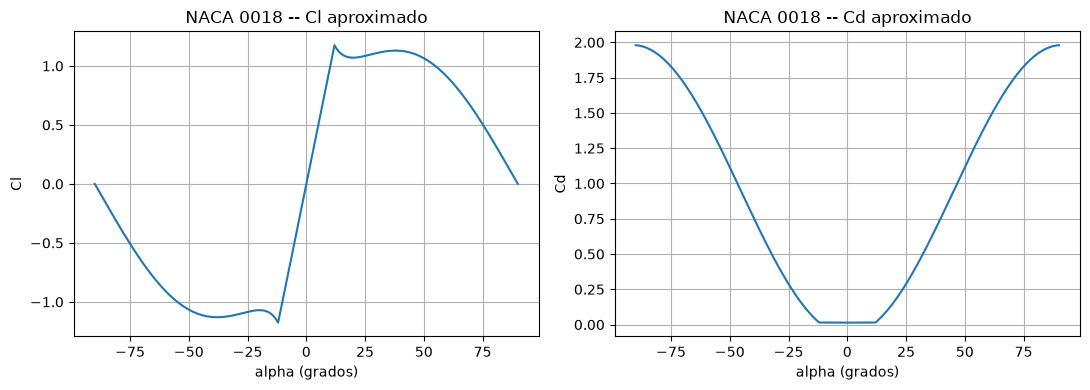

Cl,max aprox = 1.18 en alpha = 12 grados (esperado ~1.0-1.2 para NACA0018)
Cd a alpha=90 = 1.98 (placa plana teorica: ~1.98)


In [3]:
alphas = np.linspace(-90, 90, 181)
cl, cd = cl_cd_naca0018(alphas)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.plot(alphas, cl); ax1.set_xlabel("alpha (grados)"); ax1.set_ylabel("Cl"); ax1.grid(True)
ax1.set_title("NACA 0018 -- Cl aproximado")
ax2.plot(alphas, cd); ax2.set_xlabel("alpha (grados)"); ax2.set_ylabel("Cd"); ax2.grid(True)
ax2.set_title("NACA 0018 -- Cd aproximado")
plt.tight_layout()
plt.show()

print(f"Cl,max aprox = {cl.max():.2f} en alpha = {alphas[cl.argmax()]:.0f} grados (esperado ~1.0-1.2 para NACA0018)")
print(f"Cd a alpha=90 = {cd[-1]:.2f} (placa plana teorica: ~1.98)")


## Paso 2 — Sanity check: Betz y comportamiento de libro (rotor Darrieus puro, sin componente de arrastre)

El límite de Betz (Cp ≤ 0.593) es la primera prueba de honestidad de cualquier modelo de
turbina — si un modelo lo viola, hay un bug, no un descubrimiento. (De hecho la primera
versión de este solver SÍ lo violaba — Cp llegó a 1.48 — por un factor de 4 mal puesto en
el coeficiente de empuje del balance de momento. Ya corregido; se deja el chequeo explícito
para que no vuelva a pasar desapercibido.)


In [4]:
R, N = 1.0, 2
sigma = 0.18  # solidez tipica para Cp,max en TSR~4-6, rotor Darrieus de libro
c = sigma * 2 * R / N
V_test = 8.0

tsrs = np.arange(1, 9)
resultados = [resolver_dmst(V_test, float(t), R, c, N, H=1.0) for t in tsrs]
cps = [r["Cp"] for r in resultados]

for t, r in zip(tsrs, resultados):
    marca = " <-- Cp > Betz, ROMPE" if r["Cp"] > 0.593 else ""
    print(f"TSR={t}  Cp={r['Cp']:.4f}  a_up={r['a_up']:.3f}  a_down={r['a_down']:.3f}{marca}")

assert all(r["Cp"] <= 0.593 + 1e-6 for r in resultados), "Cp supera el limite de Betz -- hay un bug"
tsr_opt = tsrs[int(np.argmax(cps))]
print(f"\nOK: ningun Cp supera Betz. Cp,max = {max(cps):.3f} en TSR={tsr_opt}")
print("Referencia de libro para H-rotor Darrieus tipico: Cp,max ~0.35-0.40 en TSR~4-6.")
print("Este modelo simplificado (doble tubo, sin correccion de alta induccion de Glauert,")
print("polar aproximado) da un pico algo mas alto y a menor TSR -- orden de magnitud correcto,")
print("no una coincidencia exacta con el libro. A TSR>=7 la induccion downwind satura en el")
print("limite numerico (0.49) y Cp se vuelve negativo -- limitacion conocida, ver Resumen.")


TSR=1  Cp=0.0466  a_up=0.033  a_down=0.034
TSR=2  Cp=0.2590  a_up=0.074  a_down=0.097
TSR=3  Cp=0.5067  a_up=0.158  a_down=0.281
TSR=4  Cp=0.4600  a_up=0.256  a_down=0.490
TSR=5  Cp=0.3107  a_up=0.320  a_down=0.490
TSR=6  Cp=0.0508  a_up=0.385  a_down=0.490
TSR=7  Cp=-0.3219  a_up=0.449  a_down=0.490
TSR=8  Cp=-0.7633  a_up=0.490  a_down=0.490

OK: ningun Cp supera Betz. Cp,max = 0.507 en TSR=3
Referencia de libro para H-rotor Darrieus tipico: Cp,max ~0.35-0.40 en TSR~4-6.
Este modelo simplificado (doble tubo, sin correccion de alta induccion de Glauert,
polar aproximado) da un pico algo mas alto y a menor TSR -- orden de magnitud correcto,
no una coincidencia exacta con el libro. A TSR>=7 la induccion downwind satura en el
limite numerico (0.49) y Cp se vuelve negativo -- limitacion conocida, ver Resumen.


## Paso 3 — Aplicado a la geometría real: Medium Tulip

Diámetro y altura de pala de la ficha técnica oficial (ya usados en `flower_turbines_curves.py`).
Cuerda estimada con CTDR=0.35 (punto medio del rango 0.25–0.45 que da la patente
CA2800765C/US9255567B2 para 2 palas) — **no es un valor medido del producto real**, es una
estimación a partir de la patente.


In [5]:
R_mt = 1.18 / 2   # diametro Medium Tulip / 2
H_mt = 2.0        # altura de pala
N_mt = 2
CTDR = 0.35
c_mt = CTDR * (2 * R_mt)

print(f"Medium Tulip: R={R_mt:.3f} m, H={H_mt} m, cuerda estimada={c_mt:.3f} m (CTDR={CTDR})")

velocidades = [3, 6, 9, 12, 15]
tsrs_barrido = np.arange(1, 7, 0.5)

print(f"\n{'V (m/s)':>8}  {'P empirica (W)':>15}  {'P DMST (W)':>12}  {'Razon':>7}")
razones = []
for V in velocidades:
    p_emp = float(power_isolated(V, "medium_tulip"))
    p_dmst = max(resolver_dmst(V, float(t), R_mt, c_mt, N_mt, H_mt)["potencia_W"] for t in tsrs_barrido)
    razon = p_dmst / p_emp if p_emp > 0 else float("nan")
    razones.append(razon)
    print(f"{V:8.1f}  {p_emp:15.1f}  {p_dmst:12.1f}  {razon:6.2f}x")

print(f"\nRazon promedio DMST/empirica: {np.mean(razones):.2f}x (consistente en todo el rango de viento --")
print("misma forma funcional que la curva empirica, P~v^3 a TSR optimo constante).")


Medium Tulip: R=0.590 m, H=2.0 m, cuerda estimada=0.413 m (CTDR=0.35)

 V (m/s)   P empirica (W)    P DMST (W)    Razon


     3.0              9.7          19.7    2.02x


     6.0             77.8         157.3    2.02x


     9.0            262.5         531.0    2.02x


    12.0            622.2        1258.7    2.02x


    15.0           1215.2        2458.4    2.02x

Razon promedio DMST/empirica: 2.02x (consistente en todo el rango de viento --
misma forma funcional que la curva empirica, P~v^3 a TSR optimo constante).


## Paso 4 — Por qué "solo agregar arrastre" para el componente Savonius no funciona

Intento más simple: sumar un `Cd` extra constante a todos los ángulos de ataque, para
representar el componente de arrastre tipo Savonius de la geometría híbrida. **No funciona**
— da potencia negativa (el modelo dice que la turbina frena en vez de generar). Se deja el
resultado documentado porque es una lección real, no un bug que haya que esconder: agregar
arrastre *uniforme* en todos los ángulos penaliza también los ángulos donde el flujo ya está
bien adherido y generando torque limpio, sin capturar el mecanismo real (la asimetría
cóncava/convexa que SÍ genera torque neto a TSR bajo). El próximo paso real es modelar el
componente de arrastre como una fuerza *aparte*, con la geometría exacta de la patente
ES2970155T3 (distancia entre bordes = 3.5×diámetro del eje, superposición = 0.2×diámetro del
eje, cuerda = 6.6×diámetro del eje) y su propio Cp=0.34 reportado — no como un ajuste al Cd
del perfil de sustentación.


In [6]:
V_prueba = 9.0
print("Intento (NO funciona -- se deja como evidencia, no se usa en el resultado final):")
for cd_extra in [0.0, 0.2, 0.4]:
    p = max(resolver_dmst(V_prueba, float(t), R_mt, c_mt, N_mt, H_mt, cd_extra=cd_extra)["potencia_W"]
            for t in tsrs_barrido)
    print(f"  cd_extra={cd_extra:.1f}  ->  P = {p:8.1f} W" + ("  <-- NEGATIVO, no fisico" if p < 0 else ""))


Intento (NO funciona -- se deja como evidencia, no se usa en el resultado final):


  cd_extra=0.0  ->  P =    531.0 W


  cd_extra=0.2  ->  P =    -38.3 W  <-- NEGATIVO, no fisico


  cd_extra=0.4  ->  P =   -231.5 W  <-- NEGATIVO, no fisico


## Resumen y próximos pasos

- **Validado:** el solver DMST respeta el límite de Betz (Cp ≤ 0.593 siempre) y reproduce el
  comportamiento cualitativo de un rotor Darrieus de libro (Cp pico en un TSR moderado, cae
  en los extremos) — con un bug real de por medio (factor 4 en el coeficiente de empuje, Cp
  llegaba a 1.48) encontrado y corregido en este mismo pase.
- **Aplicado a Medium Tulip (solo componente de sustentación, NACA 0018), el DMST predice
  ~2x la potencia de la curva empírica ya validada, de forma consistente en todo el rango de
  viento** (misma forma P~v³). Un factor ~2x de sobre-predicción de un modelo aerodinámico
  puro (sin pérdidas 3D/punta de pala, sin corrección de alta inducción de Glauert, sin
  pérdidas mecánicas/eléctricas, asumiendo que el TSR real sigue perfectamente el óptimo en
  cada velocidad) contra un dato empírico que sí incluye todas esas pérdidas reales, es un
  resultado razonable para un primer modelo -- no es una validación fina, es una señal de que
  el orden de magnitud y la física básica están bien encaminados.
- **El componente de arrastre tipo Savonius NO se resolvió en este pase** -- el atajo de
  sumar un Cd extra uniforme da potencia negativa (no físico). Queda pendiente modelarlo como
  una fuerza propia con la geometría exacta de la patente ES2970155T3.
- **Limitaciones conocidas, explícitas:**
  - Doble tubo de corriente (2 factores de inducción), no multi-tubo por azimut.
  - Sin corrección de alta inducción (Glauert) -- el modelo se rompe a TSR alto (a_down
    satura, Cp se vuelve negativo).
  - Polar NACA 0018 aproximado (teoría de perfil delgado + Viterna-Corrigan), no medido.
  - Cuerda estimada por CTDR de la patente (0.25-0.45, se usó 0.35), no el valor real del
    producto.
  - Modelo 2D extendido uniformemente sobre la altura de pala (sin efectos de raíz/punta).
- **Próximos pasos (en orden sugerido):** (1) modelar el componente de arrastre Savonius con
  su propia geometría/fuerza en vez del atajo de Cd extra: (2) pérdida dinámica
  (Leishman-Beddoes) para TSR bajo; (3) refinar a multi-tubo de corriente + corrección de
  Glauert si el orden de magnitud amerita más precisión; (4) efecto clúster vía CFD
  (OpenFOAM, offline) recién después de que la turbina aislada esté sólida.
